# Phase 3: Advanced Clinical Visualization & Survival Analysis

## Project: Advanced Health Analytics & Readmission Prediction

In this phase, we move beyond basic statistics to high-impact clinical visualizations. 

### Objectives:
1. **Clinical Correlation Matrix**: Visualizing relationships between age, lab values, and stay duration.
2. **Risk-Adjusted Trend Analysis**: Comparing Glucose trends by readmission status.
3. **Survival Analysis (Time-to-Event)**: Estimating the probability of 30-day readmission over time.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for professional reporting
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.family'] = 'sans-serif'

### 1. Data Preparation
Loading the cleaned clinical dataset.

In [2]:
data_path = "../data/raw/synthetic_clinical_data.csv"
df = pd.read_csv(data_path)

# Quick clean (Consistency with Phase 1 & 2)
df_clean = df.dropna(subset=['Admission_Date']).copy()
df_clean['Hemoglobin_gdL'] = df_clean['Hemoglobin_gdL'].fillna(df_clean['Hemoglobin_gdL'].median())
df_clean['Systolic_BP'] = df_clean['Systolic_BP'].clip(60, 220)
df_clean['Glucose_mgdL'] = df_clean['Glucose_mgdL'].clip(40, 400)

print(f"Data loaded. Records: {df_clean.shape[0]}")

Data loaded. Records: 11880


### 2. Clinical Correlation Heatmap
Identifying which clinical variables move together. This helps in understanding comorbidities and preparing for feature selection in ML.

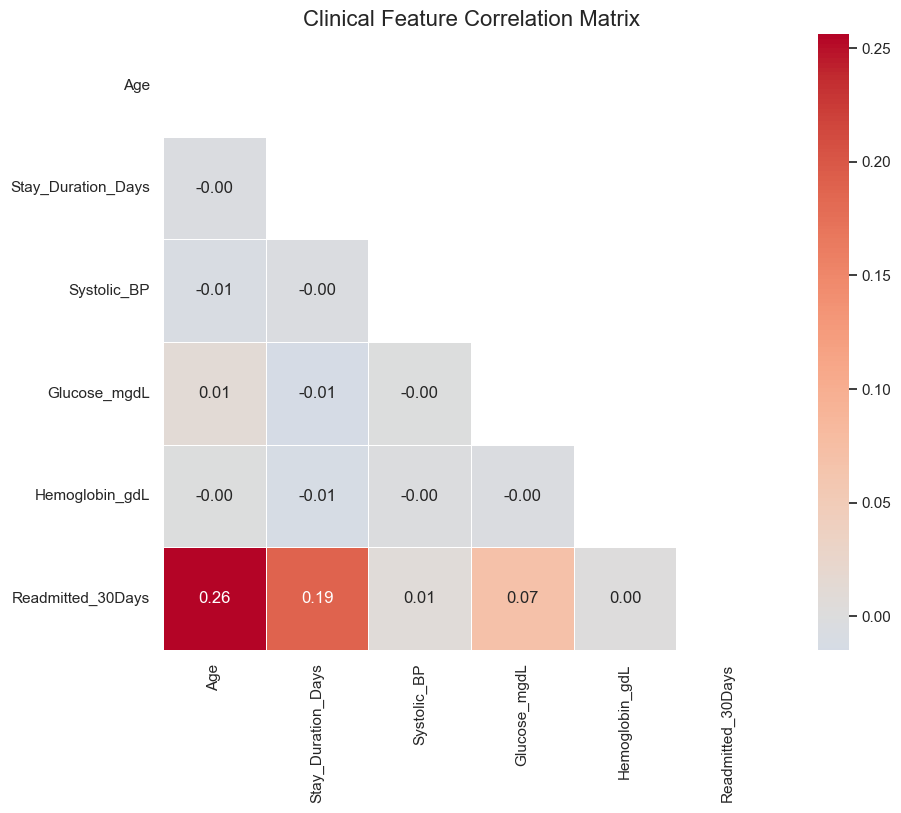

In [3]:
corr_cols = ['Age', 'Stay_Duration_Days', 'Systolic_BP', 'Glucose_mgdL', 'Hemoglobin_gdL', 'Readmitted_30Days']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title('Clinical Feature Correlation Matrix', fontsize=16)
plt.show()

### 3. Survival Analysis: Probability of Readmission
While we aren't using a dedicated library like `lifelines` yet, we can visualize the probability density of readmission over time (Stay Duration) to see the 'Hazard' curve.

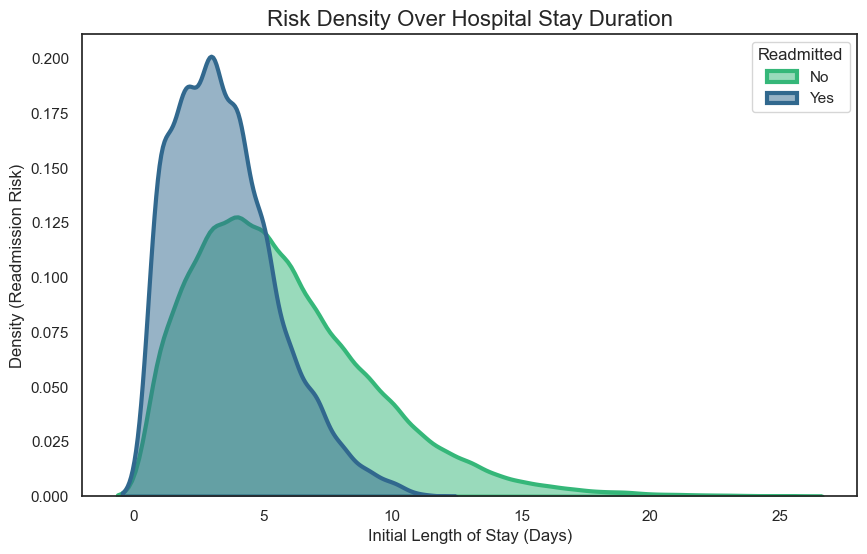

In [4]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_clean, x='Stay_Duration_Days', hue='Readmitted_30Days', fill=True, common_norm=False, palette='viridis', alpha=.5, linewidth=3)
plt.title('Risk Density Over Hospital Stay Duration', fontsize=16)
plt.xlabel('Initial Length of Stay (Days)')
plt.ylabel('Density (Readmission Risk)')
plt.legend(title='Readmitted', labels=['No', 'Yes'])
plt.show()

### 4. Executive Summary Visualization
Comparing risk levels across key comorbidities (Diabetes vs Readmission Rate) in a format suitable for clinical stakeholders.

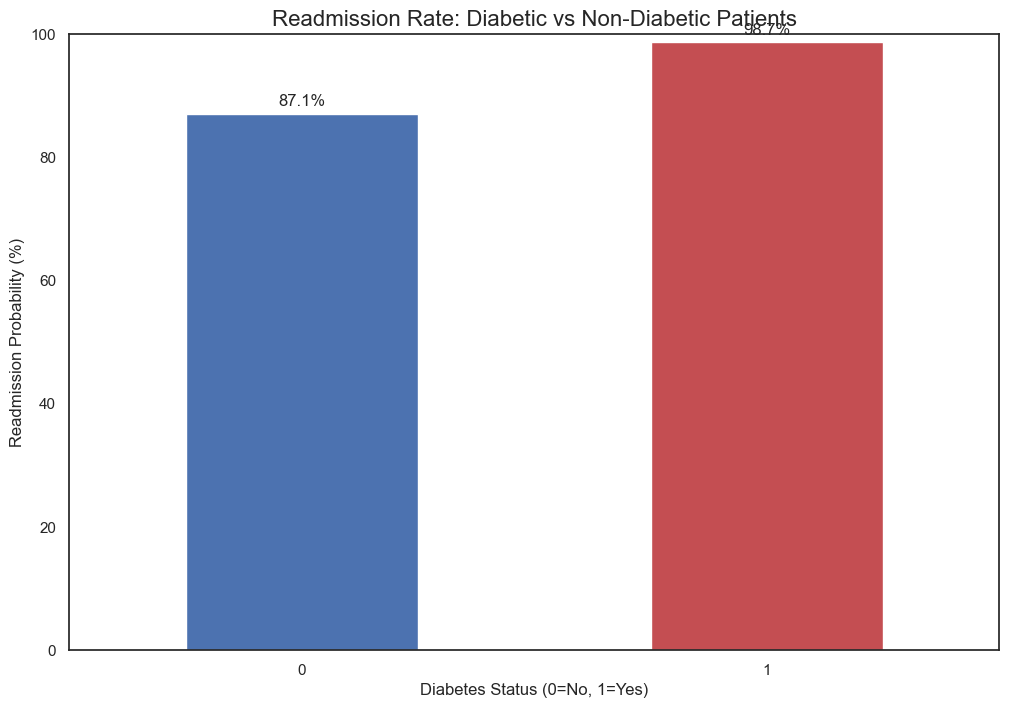

In [5]:
summary_data = df_clean.groupby('Diabetes')['Readmitted_30Days'].mean() * 100

ax = summary_data.plot(kind='bar', color=['#4C72B0', '#C44E52'], rot=0)
plt.title('Readmission Rate: Diabetic vs Non-Diabetic Patients', fontsize=16)
plt.ylabel('Readmission Probability (%)')
plt.xlabel('Diabetes Status (0=No, 1=Yes)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points', fontsize=12)
plt.ylim(0, 100)
plt.show()